In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc,
                             mean_absolute_error, mean_squared_error, r2_score)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

sns.set_theme(style="whitegrid")
RNG = 42

In [2]:
df = pd.read_csv("titanic.csv")   # NOT sns.load_dataset again
print("shape:", df.shape)

shape: (891, 15)


In [3]:
print("Class balance:\n", df["survived"].value_counts(normalize=True).round(3))
# Stratify because survived is imbalanced (~62/38). Without stratification,
# a random split could shift the minority-class ratio between train and test,
# distorting precision/recall/F1 comparisons.

feats = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X, y = df[feats], df["survived"]

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=RNG, stratify=y)
print("train:", Xtr.shape, " test:", Xte.shape)
print("train balance:", ytr.value_counts(normalize=True).round(3).to_dict())
print("test  balance:", yte.value_counts(normalize=True).round(3).to_dict())

Class balance:
 survived
0    0.616
1    0.384
Name: proportion, dtype: float64
train: (712, 7)  test: (179, 7)
train balance: {0: 0.617, 1: 0.383}
test  balance: {0: 0.615, 1: 0.385}


In [4]:
num = ["age", "sibsp", "parch", "fare"]
cat = ["sex", "embarked", "pclass"]

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), num),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore"))]), cat),
])
# Choice: median impute age (was ~20% missing), most_frequent impute embarked,
# one-hot encode categoricals, standard-scale numerics.

In [5]:
def make_pipe(est):
    return Pipeline([("pre", pre), ("clf", est)])

models = {
    "LogReg": make_pipe(LogisticRegression(max_iter=1000, random_state=RNG)),
    "Tree":   make_pipe(DecisionTreeClassifier(random_state=RNG)),
    "Forest": make_pipe(RandomForestClassifier(n_estimators=200, random_state=RNG)),
}

In [6]:
rows, roc_data = {}, {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    yp  = m.predict(Xte)
    ypr = m.predict_proba(Xte)[:, 1]
    cm  = confusion_matrix(yte, yp)
    fpr, tpr, _ = roc_curve(yte, ypr)
    rows[name] = dict(confusion=cm,
                      accuracy=accuracy_score(yte, yp),
                      precision=precision_score(yte, yp),
                      recall=recall_score(yte, yp),
                      f1=f1_score(yte, yp),
                      auc=auc(fpr, tpr))
    roc_data[name] = (fpr, tpr)
    print(f"\n--- {name} ---")
    print("confusion matrix:\n", cm)
    print(f"acc={rows[name]['accuracy']:.3f}  prec={rows[name]['precision']:.3f}  "
          f"rec={rows[name]['recall']:.3f}  f1={rows[name]['f1']:.3f}  "
          f"auc={rows[name]['auc']:.3f}")


--- LogReg ---
confusion matrix:
 [[98 12]
 [23 46]]
acc=0.804  prec=0.793  rec=0.667  f1=0.724  auc=0.843

--- Tree ---
confusion matrix:
 [[95 15]
 [20 49]]
acc=0.804  prec=0.766  rec=0.710  f1=0.737  auc=0.781

--- Forest ---
confusion matrix:
 [[97 13]
 [21 48]]
acc=0.810  prec=0.787  rec=0.696  f1=0.738  auc=0.837


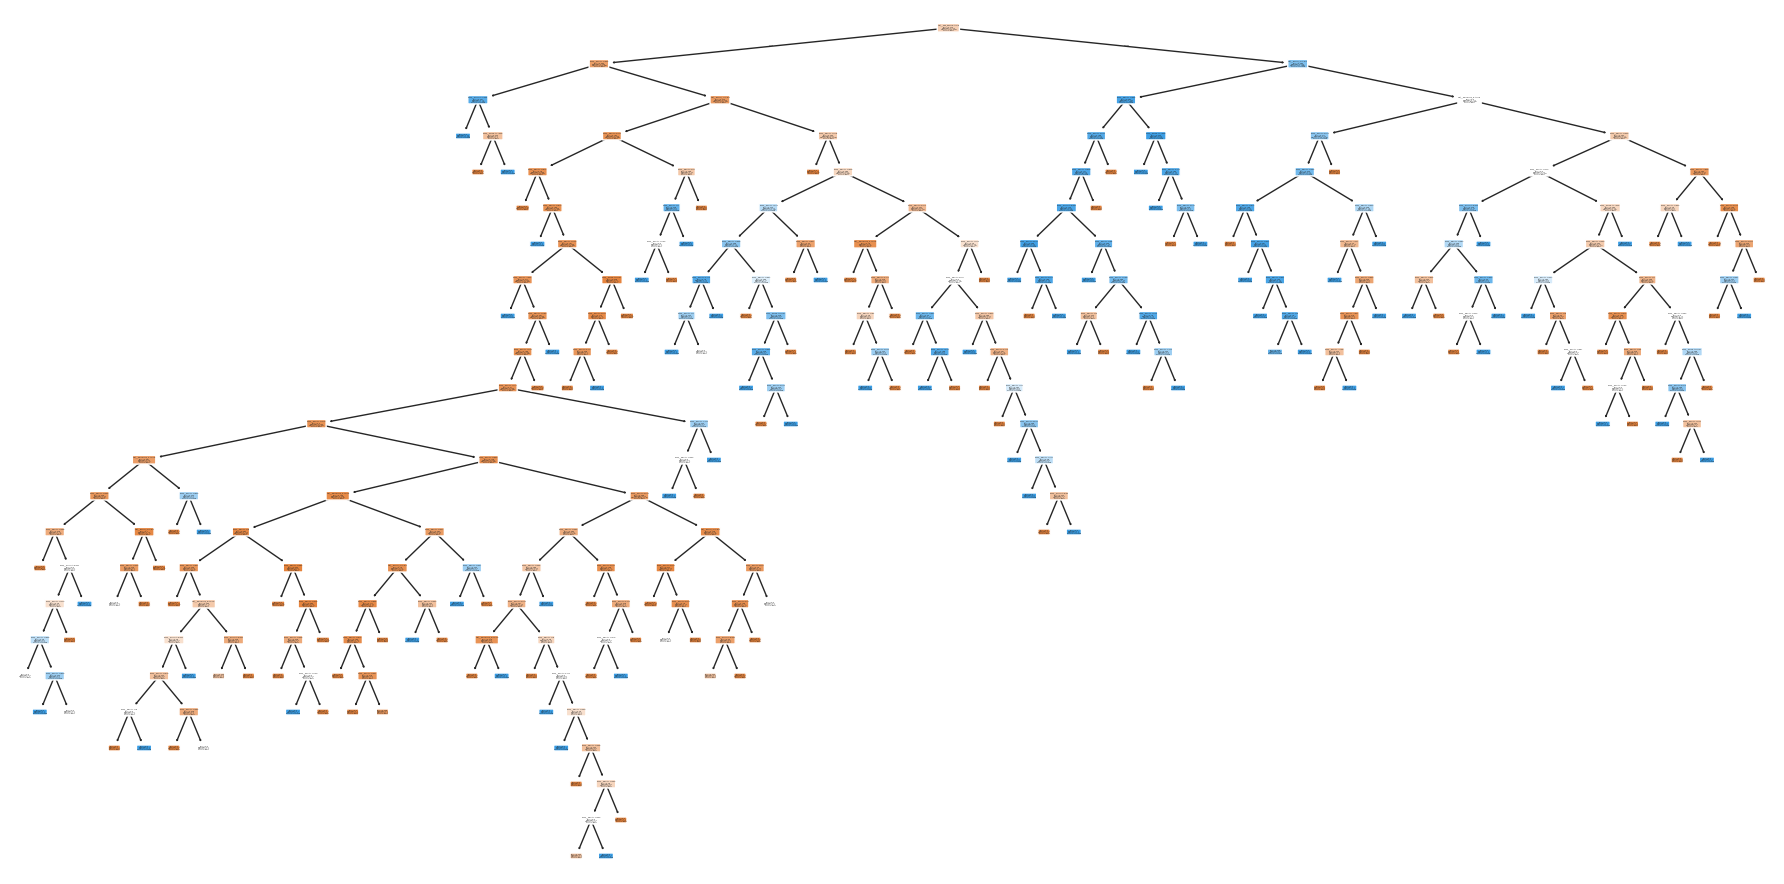

In [7]:
dt = models["Tree"]
feat_names = dt.named_steps["pre"].get_feature_names_out()

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(dt.named_steps["clf"],
          feature_names=feat_names,
          class_names=["died", "survived"],
          filled=True, rounded=True, ax=ax)
fig.tight_layout(); fig.savefig("tree.png"); plt.show()

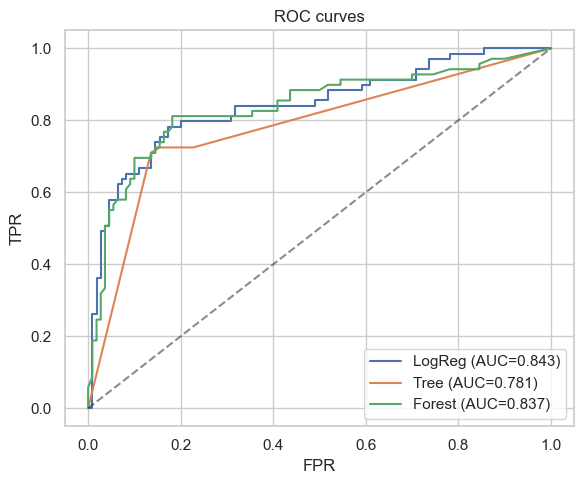

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
for n, (fpr, tpr) in roc_data.items():
    ax.plot(fpr, tpr, label=f"{n} (AUC={rows[n]['auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("ROC curves"); ax.legend()
fig.tight_layout(); fig.savefig("roc.png"); plt.show()

In [9]:
print("Balance:", y.value_counts().to_dict())

def score(p, label):
    p.fit(Xtr, ytr)
    yp = p.predict(Xte)
    return dict(label=label,
                precision=precision_score(yte, yp),
                recall=recall_score(yte, yp),
                f1=f1_score(yte, yp))

imb = pd.DataFrame([
    score(make_pipe(LogisticRegression(max_iter=1000, random_state=RNG)), "baseline"),
    score(make_pipe(LogisticRegression(max_iter=1000, random_state=RNG,
                                       class_weight="balanced")), "balanced"),
    score(ImbPipeline([("pre", pre),
                       ("smote", SMOTE(random_state=RNG)),   # train fold only
                       ("clf", LogisticRegression(max_iter=1000, random_state=RNG))]),
          "SMOTE (train only)"),
]).set_index("label").round(3)
print(imb)

Balance: {0: 549, 1: 342}
                    precision  recall     f1
label                                       
baseline                0.793   0.667  0.724
balanced                0.740   0.783  0.761
SMOTE (train only)      0.730   0.783  0.755


In [10]:
rf = RandomForestClassifier(oob_score=True, random_state=RNG, n_jobs=-1)

param_grid = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth":    [None, 5, 10],
    "clf__max_features": ["sqrt", "log2"],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
grid = GridSearchCV(make_pipe(rf), param_grid, cv=cv, scoring="f1", n_jobs=-1)
grid.fit(Xtr, ytr)

print("best params:", grid.best_params_)
print("best CV f1:", round(grid.best_score_, 3))
print("OOB score:", round(grid.best_estimator_.named_steps["clf"].oob_score_, 3))

best params: {'clf__max_depth': 10, 'clf__max_features': 'sqrt', 'clf__n_estimators': 300}
best CV f1: 0.751
OOB score: 0.819


In [11]:
reg_feats = ["pclass", "sex", "age", "sibsp", "parch", "embarked"]
Xr, yr = df[reg_feats], df["fare"]
Xrtr, Xrte, yrtr, yrte = train_test_split(Xr, yr, test_size=0.2, random_state=RNG)

pre_r = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc",  StandardScaler())]), ["age", "sibsp", "parch"]),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("oh",  OneHotEncoder(handle_unknown="ignore"))]),
     ["sex", "embarked", "pclass"]),
])
reg = Pipeline([("pre", pre_r), ("lr", LinearRegression())]).fit(Xrtr, yrtr)
pred = reg.predict(Xrte)

mae  = mean_absolute_error(yrte, pred)
rmse = np.sqrt(mean_squared_error(yrte, pred))
r2   = r2_score(yrte, pred)
n, k = len(yrte), Xrte.shape[1]
adj  = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}  Adjusted R2={adj:.3f}")

MAE=18.870  RMSE=30.920  R2=0.382  Adjusted R2=0.361


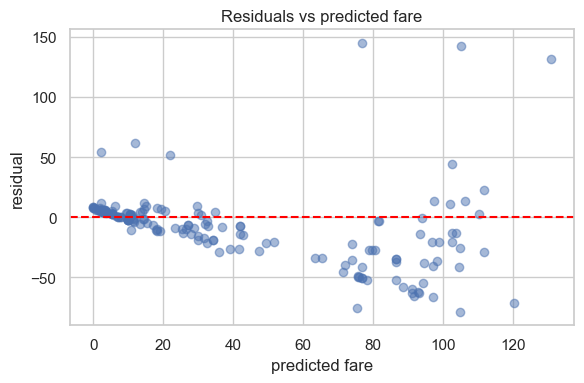

In [12]:
resid = yrte - pred
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(pred, resid, alpha=0.5); ax.axhline(0, color="red", ls="--")
ax.set_xlabel("predicted fare"); ax.set_ylabel("residual")
ax.set_title("Residuals vs predicted fare")
fig.tight_layout(); fig.savefig("resid.png"); plt.show()

In [13]:
clf_tbl = pd.DataFrame({
    n: {"accuracy": r["accuracy"], "precision": r["precision"],
        "recall": r["recall"], "f1": r["f1"], "auc": r["auc"]}
    for n, r in rows.items()
}).T.round(3)
print("Classifier metrics:\n", clf_tbl, "\n")

reg_tbl = pd.DataFrame({
    "LinearRegression(fare)": {"MAE": mae, "RMSE": rmse, "R2": r2, "AdjR2": adj}
}).T.round(3)
print("Regression metrics (different scale — not comparable to classifier metrics):\n", reg_tbl)

Classifier metrics:
         accuracy  precision  recall     f1    auc
LogReg     0.804      0.793   0.667  0.724  0.843
Tree       0.804      0.766   0.710  0.737  0.781
Forest     0.810      0.787   0.696  0.738  0.837 

Regression metrics (different scale — not comparable to classifier metrics):
                           MAE   RMSE     R2  AdjR2
LinearRegression(fare)  18.87  30.92  0.382  0.361


In [14]:
best = clf_tbl["f1"].idxmax()
print(f"Deploy: {best}")
print(f"  accuracy={clf_tbl.loc[best,'accuracy']}, "
      f"precision={clf_tbl.loc[best,'precision']}, "
      f"recall={clf_tbl.loc[best,'recall']}, "
      f"f1={clf_tbl.loc[best,'f1']}, "
      f"auc={clf_tbl.loc[best,'auc']}")

Deploy: Forest
  accuracy=0.81, precision=0.787, recall=0.696, f1=0.738, auc=0.837


In [15]:
best_pipe = grid.best_estimator_     # preprocess + classifier together
joblib.dump(best_pipe, "best_pipeline.joblib")
print("saved best_pipeline.joblib")

saved best_pipeline.joblib


In [16]:
loaded = joblib.load("best_pipeline.joblib")

raw_new = pd.DataFrame([
    {"pclass": 1, "sex": "female", "age": 29.0, "sibsp": 0, "parch": 0,
     "fare": 211.34, "embarked": "S"},
    {"pclass": 3, "sex": "male",   "age": 22.0, "sibsp": 0, "parch": 0,
     "fare": 7.25,   "embarked": "S"},
])
print("predictions:", loaded.predict(raw_new))
print("probs(survived):", loaded.predict_proba(raw_new)[:, 1].round(3))

predictions: [1 0]
probs(survived): [0.99  0.047]
